<a href="https://colab.research.google.com/github/thanu-george/ML-algorithms/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [13]:
def load_and_preprocess_unsupervised(path):
    df = pd.read_csv(path)
    print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

    # Handle missing values
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].mean(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)

    # Separate numeric and categorical
    num_df = df.select_dtypes(include=['int64', 'float64'])
    cat_df = df.select_dtypes(include=['object'])

    # One-hot encode categorical
    if not cat_df.empty:
        encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
        cat_encoded = encoder.fit_transform(cat_df)
        cat_columns = encoder.get_feature_names_out(cat_df.columns)

        cat_df = pd.DataFrame(cat_encoded, columns=cat_columns)

        df_processed = pd.concat([num_df.reset_index(drop=True),
                                 cat_df.reset_index(drop=True)], axis=1)
        print(f"One-hot encoded {len(cat_columns)} categorical features")
    else:
        df_processed = num_df

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_processed)

    return X_scaled, df_processed.columns


In [15]:
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")


path = input("Enter CSV path (default: data.csv): ").strip() or "data.csv"

X, features = load_and_preprocess_unsupervised(path)

max_comp = min(X.shape[0], X.shape[1])

n = input(f"Number of components (max {max_comp}, default = all): ").strip()
n_components = int(n) if n else max_comp


PRINCIPAL COMPONENT ANALYSIS (PCA)
Enter CSV path (default: data.csv): /content/sample_data/mnist_train_small.csv
Loaded: 19999 rows × 785 columns
Number of components (max 785, default = all): 6


In [16]:
# PCA
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

In [17]:
print("PCA Results")

for i, (var, cum) in enumerate(zip(evr, cumulative)):
    print(f"PC{i+1}: Variance = {var:.4f} | Cumulative = {cum:.4f}")

print(f"Total explained variance: {cumulative[-1]:.4f}")

PCA Results
PC1: Variance = 0.0591 | Cumulative = 0.0591
PC2: Variance = 0.0428 | Cumulative = 0.1019
PC3: Variance = 0.0390 | Cumulative = 0.1409
PC4: Variance = 0.0299 | Cumulative = 0.1708
PC5: Variance = 0.0259 | Cumulative = 0.1967
PC6: Variance = 0.0228 | Cumulative = 0.2195
Total explained variance: 0.2195


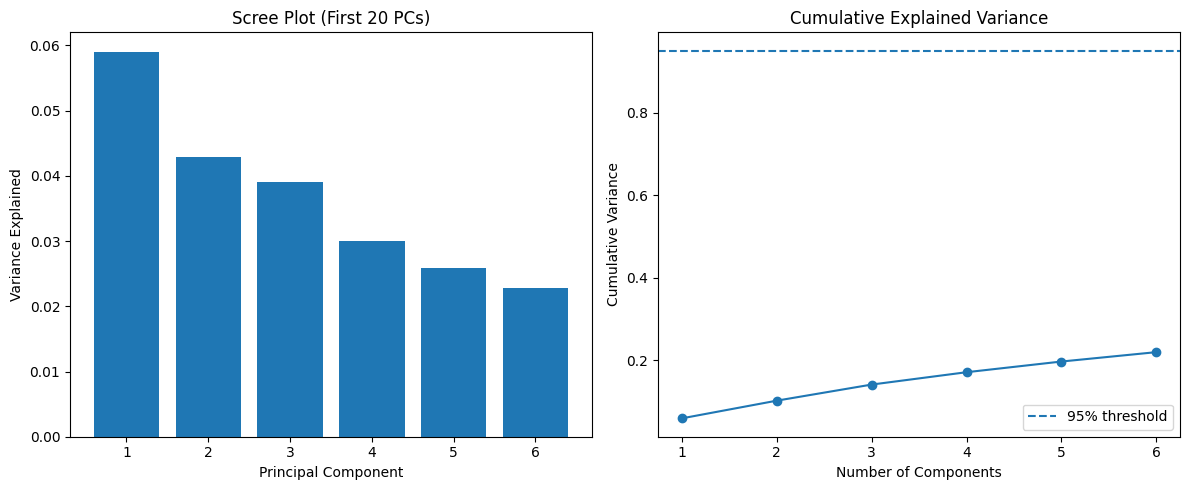

In [18]:
num_display = min(len(evr), 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
axes[0].bar(range(1, num_display+1), evr[:num_display])
axes[0].set_title('Scree Plot (First 20 PCs)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')

# Cumulative plot
axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o')
axes[1].axhline(y=0.95, linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()